# 🏫 Capacity Analysis — Predicted Capacity Deficit

---

## Tujuan
Menganalisis kapasitas tampung sekolah (SD+SMP) per kecamatan dan mengidentifikasi
**Predicted Capacity Deficit** — selisih antara proyeksi demand siswa dengan kapasitas
yang tersedia pada tahun horizon 2030.

---

## Formula

$$\text{Kapasitas} = \max(\text{Pagu Siswa}_{2025}, \text{Murid Aktual})$$

$$\text{Gap} = \text{Demand}_{Y} - \text{Kapasitas}$$

$$\text{Utilisasi} = \frac{\text{Demand}_{Y}}{\text{Kapasitas}} \times 100\%$$

$$\text{Siswa Tak Tertampung} = \max(0, \text{Gap})$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DATA = '../medallion/exports/'

kap  = pd.read_csv(DATA + 'kapasitas.csv')
gap  = pd.read_csv(DATA + 'gap_analysis.csv')
rekom = pd.read_csv(DATA + 'rekomendasi.csv')

print('Kapasitas:', kap.shape, '| Gap:', gap.shape)
kap.head()

Kapasitas: (32, 7) | Gap: (186, 8)


,kecamatan_key,kecamatan_norm,kapasitas,total_pagu,murid_aktual,total_ruang_kelas,jumlah_sekolah
0,GENTENG,GENTENG,9698,4933,9698,314,18
1,NaN,NaN,0,0,0,45,14
2,SAWAHAN,SAWAHAN,16672,12661,16672,570,41
3,SUKOMANUNGGAL,SUKOMANUNGGAL,14210,8428,14210,311,25
4,ASEMROWO,ASEMROWO,5333,3435,5333,57,14


## 1. Kapasitas vs Demand 2030 — Overview

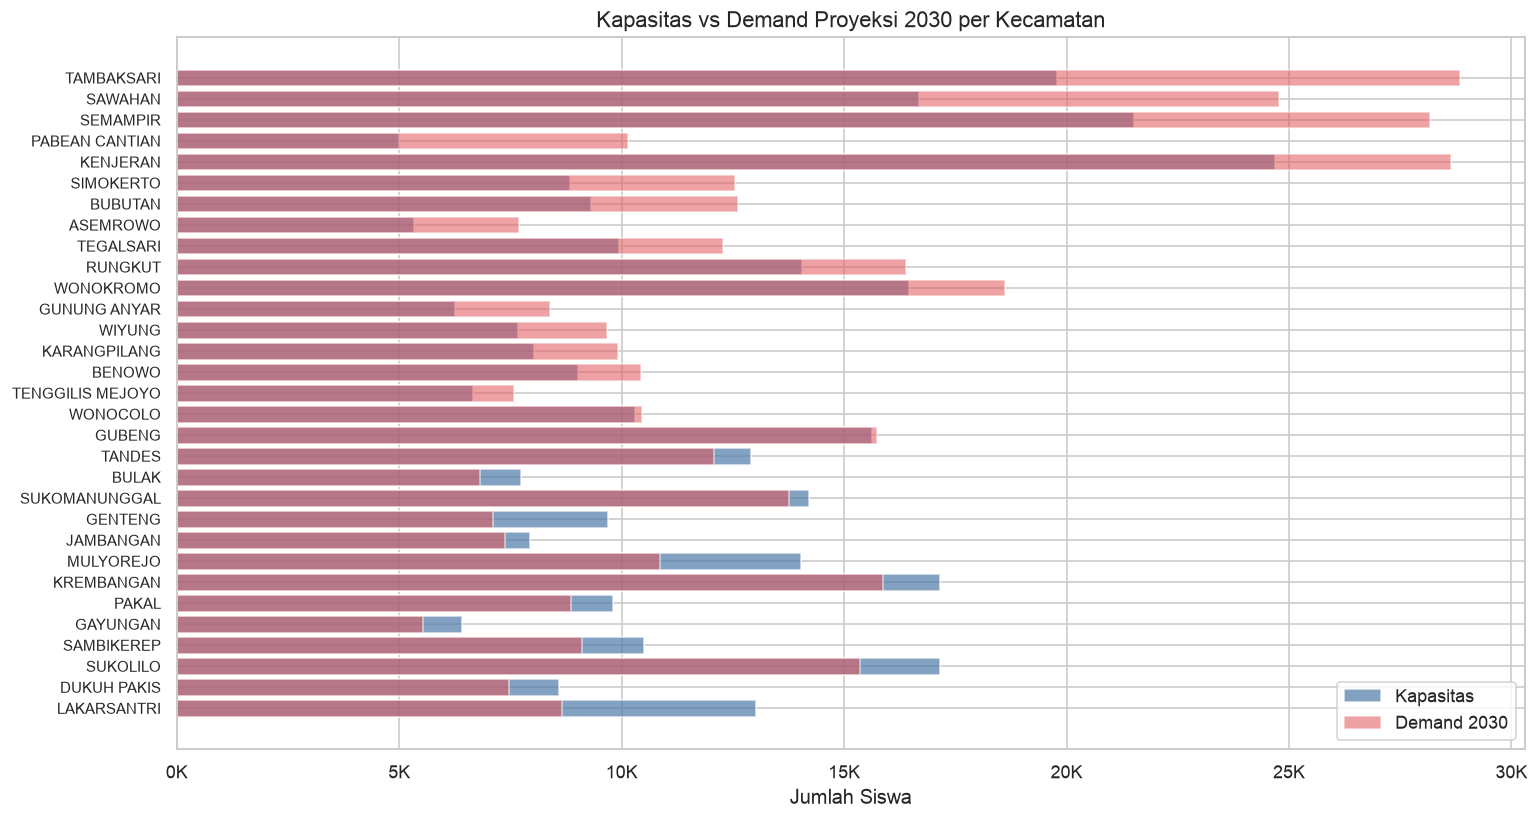

In [2]:
g30 = gap[gap['tahun_proyeksi']==2030].sort_values('siswa_tak_tertampung', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
y = np.arange(len(g30))
ax.barh(y, g30['kapasitas'], color='#4E79A7', alpha=0.7, label='Kapasitas')
ax.barh(y, g30['demand_total'], color='#E15759', alpha=0.55, label='Demand 2030')
ax.set_yticks(y)
ax.set_yticklabels(g30['kecamatan_norm'], fontsize=9)
ax.set_xlabel('Jumlah Siswa')
ax.set_title('Kapasitas vs Demand Proyeksi 2030 per Kecamatan')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.axvline(0, color='black', lw=0.5)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. Utilisasi Kapasitas per Tahun

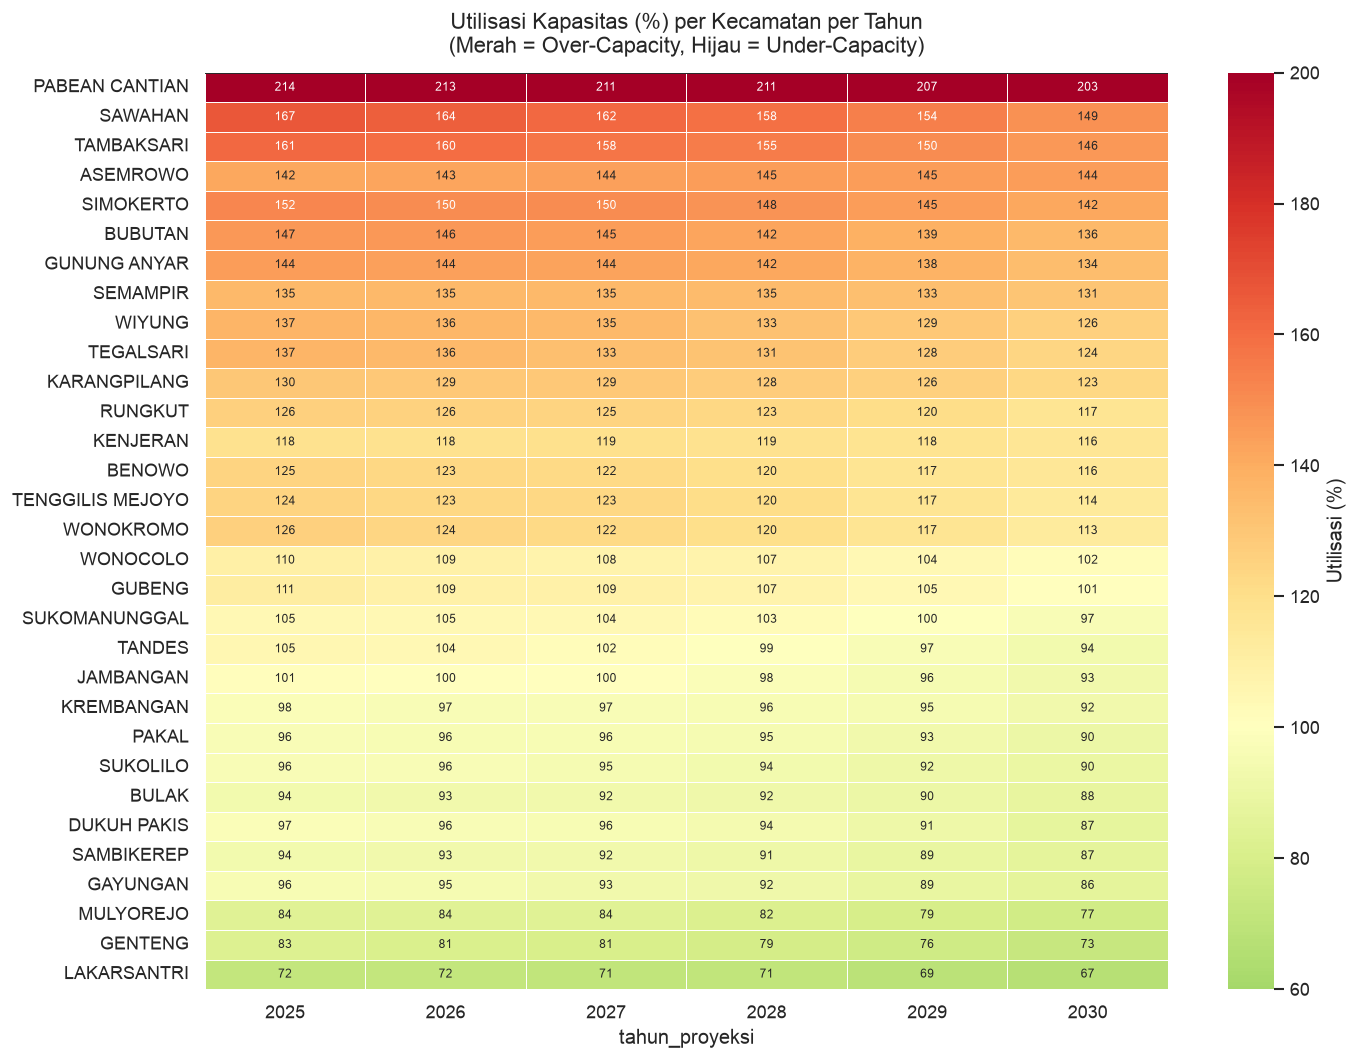

In [3]:
util_pivot = gap.pivot_table(index='kecamatan_norm', columns='tahun_proyeksi',
                              values='utilisasi_pct').sort_values(2030, ascending=False)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(util_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            center=100, vmin=60, vmax=200,
            linewidths=0.3, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'Utilisasi (%)'})
ax.set_title('Utilisasi Kapasitas (%) per Kecamatan per Tahun\n(Merah = Over-Capacity, Hijau = Under-Capacity)', pad=12)
ax.set_ylabel('')
ax.axhline(0, color='black', lw=1)
plt.tight_layout()
plt.show()

## 3. Siswa Tak Tertampung — Defisit Kumulatif 2025-2030

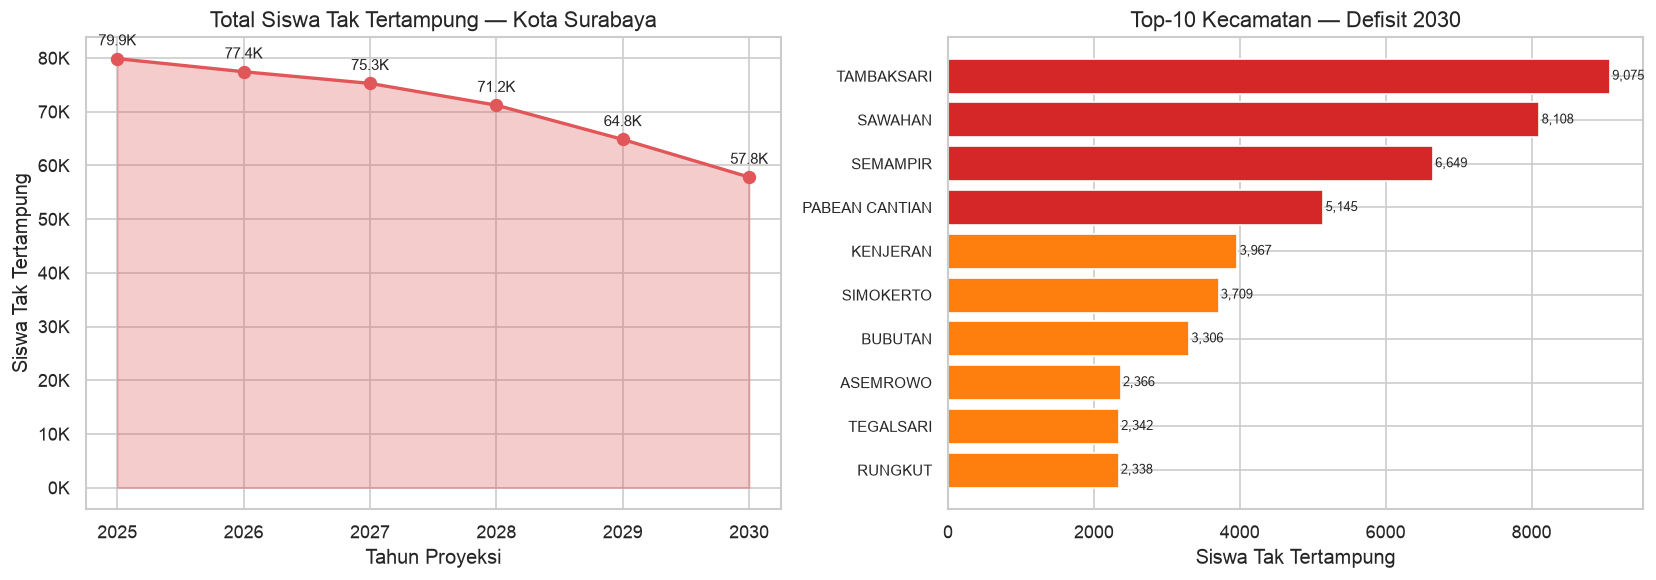

In [4]:
deficit_trend = (gap.groupby('tahun_proyeksi')['siswa_tak_tertampung']
                    .sum().reset_index(name='total_deficit'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trend total deficit
ax1 = axes[0]
ax1.fill_between(deficit_trend['tahun_proyeksi'], deficit_trend['total_deficit'],
                  alpha=0.3, color='#E15759')
ax1.plot(deficit_trend['tahun_proyeksi'], deficit_trend['total_deficit'],
          'o-', color='#E15759', lw=2, ms=7)
for _, row in deficit_trend.iterrows():
    ax1.annotate(f"{row['total_deficit']/1000:.1f}K",
                 (row['tahun_proyeksi'], row['total_deficit']),
                 textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax1.set_title('Total Siswa Tak Tertampung — Kota Surabaya')
ax1.set_xlabel('Tahun Proyeksi')
ax1.set_ylabel('Siswa Tak Tertampung')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Top-10 kecamatan defisit 2030
ax2 = axes[1]
top10 = g30.head(10)
colors = ['#d62728' if v > 5000 else '#ff7f0e' if v > 2000 else '#2ca02c'
          for v in top10['siswa_tak_tertampung']]
bars = ax2.barh(range(10), top10['siswa_tak_tertampung'], color=colors)
ax2.set_yticks(range(10))
ax2.set_yticklabels(top10['kecamatan_norm'], fontsize=9)
ax2.set_xlabel('Siswa Tak Tertampung')
ax2.set_title('Top-10 Kecamatan — Defisit 2030')
ax2.invert_yaxis()
for bar, val in zip(bars, top10['siswa_tak_tertampung']):
    ax2.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Distribusi Utilisasi & Scatter Kapasitas

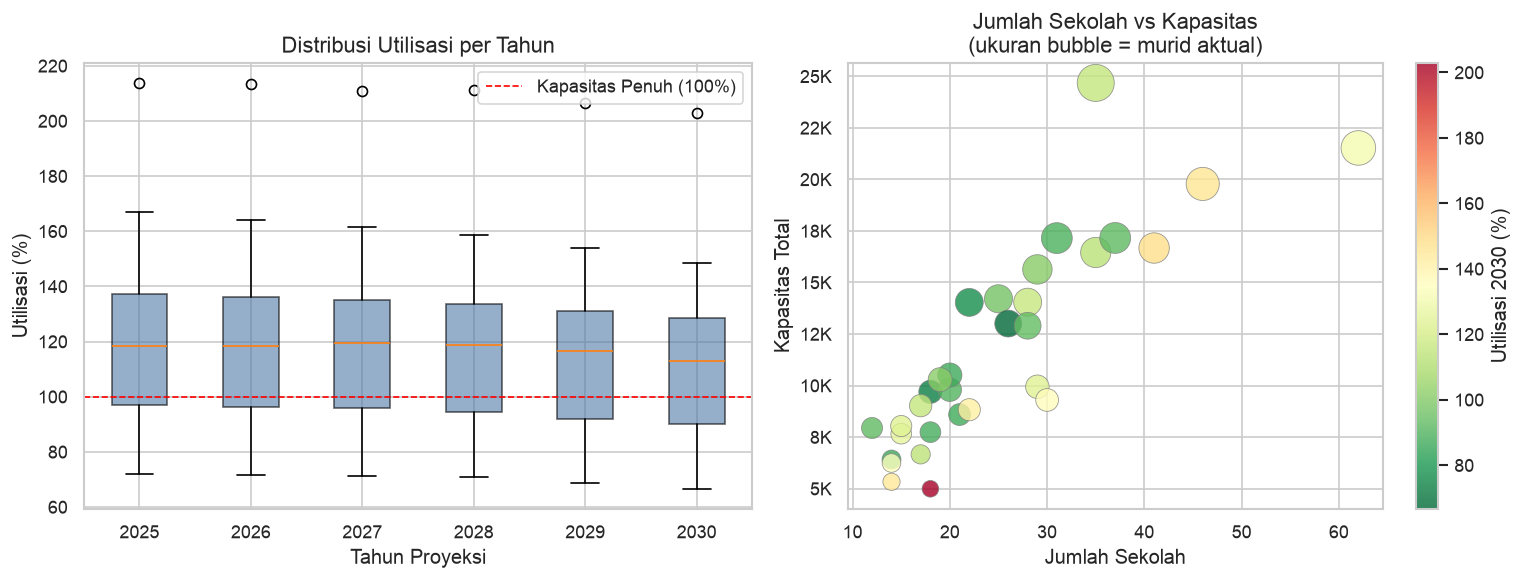

In [5]:
g25 = gap[gap['tahun_proyeksi']==2025]
g30_scat = gap[gap['tahun_proyeksi']==2030]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box-plot utilisasi per tahun
util_box = gap.pivot_table(index='kecamatan_norm', columns='tahun_proyeksi',
                            values='utilisasi_pct')
# SESUDAH (fix untuk matplotlib 3.11):
axes[0].boxplot(util_box.values, tick_labels=[str(int(c)) for c in util_box.columns],
                patch_artist=True,
                boxprops=dict(facecolor='#4E79A7', alpha=0.6))
axes[0].axhline(100, color='red', ls='--', lw=1, label='Kapasitas Penuh (100%)')
axes[0].set_title('Distribusi Utilisasi per Tahun')
axes[0].set_xlabel('Tahun Proyeksi')
axes[0].set_ylabel('Utilisasi (%)')
axes[0].legend()

# Scatter: jumlah sekolah vs kapasitas
merged = kap.merge(g30_scat[['kecamatan_key','utilisasi_pct']], on='kecamatan_key', how='left')
sc = axes[1].scatter(merged['jumlah_sekolah'], merged['kapasitas'],
                      c=merged['utilisasi_pct'], cmap='RdYlGn_r',
                      s=merged['murid_aktual']/50, alpha=0.8, edgecolors='grey', lw=0.5)
plt.colorbar(sc, ax=axes[1], label='Utilisasi 2030 (%)')
axes[1].set_xlabel('Jumlah Sekolah')
axes[1].set_ylabel('Kapasitas Total')
axes[1].set_title('Jumlah Sekolah vs Kapasitas\n(ukuran bubble = murid aktual)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

---
## 📌 Ringkasan Capacity Analysis

Sel berikut mencetak ringkasan statistik key metrics.

In [6]:
total_cap   = kap['kapasitas'].sum()
total_d2030 = g30['demand_total'].sum()
total_def   = g30['siswa_tak_tertampung'].sum()
over_cap    = (g30['utilisasi_pct'] > 100).sum()

print('='*55)
print('  RINGKASAN CAPACITY ANALYSIS')
print('='*55)
print(f'  Total Kapasitas  (saat ini) : {total_cap:>10,.0f} siswa')
print(f'  Total Demand     (2030)     : {total_d2030:>10,.0f} siswa')
print(f'  Deficit Proyeksi (2030)     : {total_def:>10,.0f} siswa')
print(f'  Over-Capacity Kecamatan     : {over_cap:>10} dari 31')
print(f'  Global Utilisasi (2030)     : {total_d2030/total_cap*100:>9.1f}%')
print('='*55)

# Rekomendasi summary
print('\n  Distribusi Rekomendasi USB/RKB:')
print(rekom['rekomendasi'].value_counts().to_string())

  RINGKASAN CAPACITY ANALYSIS
  Total Kapasitas  (saat ini) :    364,288 siswa
  Total Demand     (2030)     :    401,789 siswa
  Deficit Proyeksi (2030)     :     57,817 siswa
  Over-Capacity Kecamatan     :         18 dari 31
  Global Utilisasi (2030)     :     110.3%

  Distribusi Rekomendasi USB/RKB:
rekomendasi
USB      16
CUKUP    13
RKB       2
